# Activity 1. Data Loading and Preprocessing

## 1. Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import seaborn as sns

# Load the BBC News Classification dataset
data = pd.read_csv(
    "https://raw.githubusercontent.com/suraj-deshmukh/BBC-Dataset-News-Classification/refs/heads/master/dataset/dataset.csv", encoding='iso8859-1')

## Explore the Dataset

### a) Display the first 3 rows

In [2]:
data.head(3)

,news,type
0,China had role in Yukos split-up\n \n China le...,business
1,Oil rebounds from weather effect\n \n Oil pric...,business
2,Indonesia 'declines debt freeze'\n \n Indonesi...,business


### b) Show the distribution of types

type
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


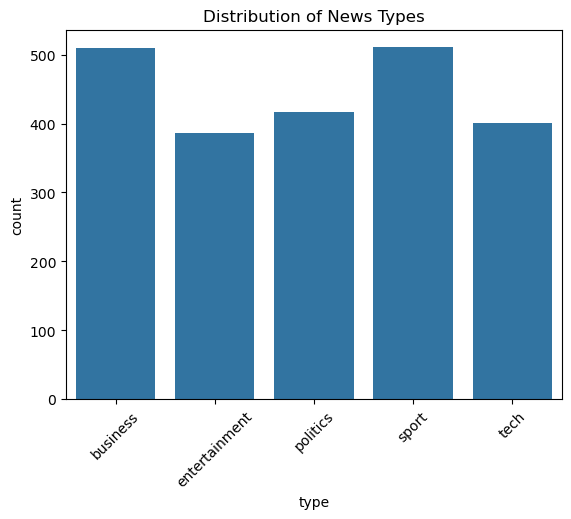

In [3]:
type_counts = data['type'].value_counts()
print(type_counts)

sns.countplot(x='type', data=data)
plt.title('Distribution of News Types')
plt.xticks(rotation=45)
plt.show()

### c) Calculate average text length by category

In [4]:
data['text_length'] = data['news'].str.len()
avg_length_by_type = data.groupby('type')['text_length'].mean()
avg_length_by_type

type
business         1996.194118
entertainment    1938.230570
politics         2695.824940
sport            1906.545988
tech             2987.690773
Name: text_length, dtype: float64

# Activity 2. Document Similarity and K-Nearest Neighbors

## 1. Create Document Representations

### a) Create TF-IDF representation using `TfidfVectorizer` (max_features=1000)

In [5]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(data['news'])
feature_names = tfidf_vectorizer.get_feature_names_out()

### b)	Display the matrix shape

In [6]:
tfidf_matrix.shape

(2225, 1000)

## Measure Similarity

### a)	Calculate cosine similarity between the first two news

In [7]:
sim_0_1 = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0, 0]
print("Cosine similarity between news 0 and news 1:", sim_0_1)

Cosine similarity between news 0 and news 1: 0.4251092622617505


### b)	Find the 3 most similar documents to the first news in the dataset using NearestNeighbors

In [8]:
nn_model = NearestNeighbors(metric='cosine', n_neighbors=4)
nn_model.fit(tfidf_matrix)

distances, indices = nn_model.kneighbors(tfidf_matrix[0])

print("Indices of neighbors:", indices[0][1:])
print("Distances (cosine distance):", distances[0][1:])

Indices of neighbors: [458  56 266]
Distances (cosine distance): [0.3130579  0.33216409 0.33774334]


### c)	Display their news text, types, and similarity scores

In [9]:
neighbor_indices = indices[0][1:4]
neighbor_distances = distances[0][1:4]

print("Most similar 3 documents to news 0:\n")

for rank, (idx, dist) in enumerate(zip(neighbor_indices, neighbor_distances), start=1):
    similarity = 1 - dist
    print(f"Rank {rank}")
    print(f"Index: {idx}")
    print(f"Type: {data.loc[idx, 'type']}")
    print(f"Similarity: {similarity:.4f}")
    print("News text (first 300 chars):")
    print(data.loc[idx, 'news'][:300], "...")
    print("-" * 80)

Most similar 3 documents to news 0:

Rank 1
Index: 458
Type: business
Similarity: 0.6869
News text (first 300 chars):
Indian oil firm eyes Yukos assets
 
 India's biggest oil exploration firm, Oil & Natural Gas Corp (ONGC), says it is in talks to buy the former assets of troubled Russian crude producer Yukos.
 
 "We are in touch with the concerned Russian entities about the Yukos assets and other opportunities in R ...
--------------------------------------------------------------------------------
Rank 2
Index: 56
Type: business
Similarity: 0.6678
News text (first 300 chars):
Yukos unit fetches $9bn at auction
 
 A little-known Russian company has bought the main production unit of oil giant Yukos at auction in Moscow.
 
 Baikal Finance Group outbid favourite Gazprom, the state-controlled gas monopoly, to buy Yuganskneftegas. Baikal paid 260.75bn roubles ($9.37bn: Â£4.8b ...
--------------------------------------------------------------------------------
Rank 3
Index: 266
Type: busine

# Activity 3. K-means Clustering

## Apply Clustering
### a) Apply k-means with k=5 clusters using TF-IDF matrix (random_state=42)

In [10]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)
kmeans

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


### b) Add cluster labels to the dataframe

In [11]:
cluster_labels = kmeans.labels_
data['cluster'] = cluster_labels
data[['news', 'type', 'cluster']].head()

,news,type,cluster
0,China had role in Yukos split-up\n \n China le...,business,2
1,Oil rebounds from weather effect\n \n Oil pric...,business,2
2,Indonesia 'declines debt freeze'\n \n Indonesi...,business,2
3,$1m payoff for former Shell boss\n \n Shell is...,business,2
4,US bank in $515m SEC settlement\n \n Five Bank...,business,2


### c) Show cluster distribution vs actual type distribution

In [12]:
print("Actual type distribution:")
print(data['type'].value_counts())
print("\nCluster distribution:")
print(data['cluster'].value_counts())

crosstab = pd.crosstab(data['cluster'], data['type'])
print("\nCluster vs Type crosstab:")
print(crosstab)

Actual type distribution:
type
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Cluster distribution:
cluster
1    667
3    525
2    507
4    269
0    257
Name: count, dtype: int64

Cluster vs Type crosstab:
type     business  entertainment  politics  sport  tech
cluster                                                
0               0            249         0      3     5
1              40             75       145     25   382
2             458             17        16      3    13
3               1             41         3    480     0
4              11              4       253      0     1


## Analyze the results
### a) For each cluster, display the top 10 most important words

In [13]:
cluster_centers = kmeans.cluster_centers_
top_n = 10

for cluster_id in range(k):
    center = cluster_centers[cluster_id]
    top_indices = center.argsort()[::-1][:top_n]
    top_words = [feature_names[i] for i in top_indices]

    print(f"Cluster {cluster_id} top {top_n} words:")
    print(", ".join(top_words))
    print("-" * 80)

Cluster 0 top 10 words:
the, film, in, and, of, to, best, for, awards, award
--------------------------------------------------------------------------------
Cluster 1 top 10 words:
the, to, of, and, in, that, is, it, for, said
--------------------------------------------------------------------------------
Cluster 2 top 10 words:
the, to, in, of, and, its, said, it, for, us
--------------------------------------------------------------------------------
Cluster 3 top 10 words:
the, to, in, and, he, of, his, was, for, but
--------------------------------------------------------------------------------
Cluster 4 top 10 words:
the, to, mr, he, of, and, labour, in, blair, election
--------------------------------------------------------------------------------


### b) Based on top words, assign meaningful names to each cluster

In [14]:
cluster_names = {
    0: "Entertainment / Film News",
    1: "General News",
    2: "International Politics",
    3: "Human Interest News",
    4: "UK Politics"
}

data['cluster_name'] = data['cluster'].map(cluster_names)
data[['type', 'cluster', 'cluster_name']].head()

,type,cluster,cluster_name
0,business,2,International Politics
1,business,2,International Politics
2,business,2,International Politics
3,business,2,International Politics
4,business,2,International Politics
